In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp
import matplotlib.pyplot as plt
from GraphST import GraphST
# clustering
from GraphST.utils import clustering


### Global variables

In [2]:
# Run device, by default, the package is implemented on 'cpu'. We recommend using GPU.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# the location of R, which is necessary for mclust algorithm. Please replace the path below with local R installation path
os.environ['R_HOME'] = '/usr/lib/R'

n_clusters = 11 #12

# set radius to specify the number of neighbors considered during refinement
radius = 50

tool = 'mclust' # mclust, leiden, and louvain


In [3]:
def save_file(adata, results_path):
    
    # Extract cell IDs and predicted cluster labels
    cell_ids = adata.obs.index.tolist()  # Extract cell IDs
    predicted_clusters = adata.obs['domain'].tolist()  # Change 'leiden' to the actual column name containing cluster labels
    
    # Create a DataFrame with the extracted data
    data_dict = {
        'Id': cell_ids,
        'Expected': predicted_clusters
    }
    df = pd.DataFrame(data_dict)
    df.to_csv(results_path, index = False)
    

(1950, 32285)
Begin to train ST data...


100%|██████████████████████████████████████████████████████████████████| 600/600 [00:09<00:00, 61.08it/s]


Optimization finished for ST data!


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


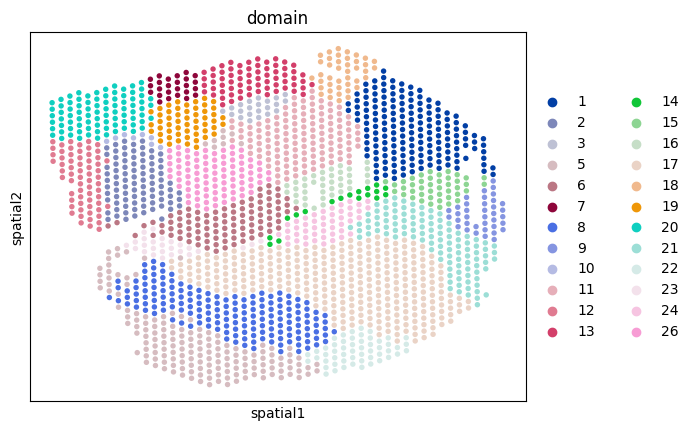

In [4]:

method_name = "GraphST"
path = "/data/Ajita/Spatial/Datasets/Spatial_Domain/Real_datasets/mouse_breast_cancer/mouse_breast_cancer.h5ad"

results_path = "/data/Ajita/Spatial/Datasets/Spatial_Domain/Real_datasets/mouse_breast_cancer/final_domain_outputs/" \
+ "/output_" + method_name + ".csv"
adata = sc.read_h5ad(path)

print (adata.shape)

adata.var_names_make_unique()

# define model
model = GraphST.GraphST(adata, device=device)

# train model
adata = model.train()

if tool == 'mclust':
   clustering(adata, n_clusters, radius=radius, method=tool, refinement=True) # For DLPFC dataset, we use optional refinement step.
elif tool in ['leiden', 'louvain']:
   clustering(adata, n_clusters, radius=radius, method=tool, start=0.1, end=2.0, increment=0.01, refinement=False)

sc.pl.embedding(adata, basis = "spatial", color = "domain")
"""
# plotting predicted labels by UMAP
sc.pp.neighbors(adata, use_rep='emb_pca', n_neighbors=10)
sc.tl.umap(adata)
sc.pl.umap(adata, color='domain', title = ['Predicted labels'], show=False)
"""
save_file(adata, results_path)
